In [2]:
import pandas as pd

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
base_path = 'C:/Users/University/DATA SCI & BUSINESS/GOLD/Gold Import/'
file_name = 'TradeData.xlsx'
years = range(2019, 2025)
list_years = list(years)
print(list_years)

[2019, 2020, 2021, 2022, 2023, 2024]


In [155]:
dataframes = []

In [156]:
for year in years:
    file_path = f"{base_path}{year}\\{file_name}"  # Construct the full file path
    df = pd.read_excel(file_path)  # Read the Excel file
    dataframes.append(df)  # Append the DataFrame to the list

In [157]:
#union - combining data of all the years
combined_df = pd.concat(dataframes, ignore_index=True)

print(combined_df.head()) 

  typeCode freqCode  refPeriodId  refYear  refMonth  period  reporterCode  \
0        C        A     20190101     2019        52    2019            20   
1        C        A     20190101     2019        52    2019            24   
2        C        A     20190101     2019        52    2019            28   
3        C        A     20190101     2019        52    2019            31   
4        C        A     20190101     2019        52    2019            32   

  reporterISO         reporterDesc flowCode  ...     netWgt  \
0         AND              Andorra        M  ...     63.414   
1         AGO               Angola        M  ...        NaN   
2         ATG  Antigua and Barbuda        M  ...      0.050   
3         AZE           Azerbaijan        M  ...  49607.032   
4         ARG            Argentina        M  ...      2.140   

   isNetWgtEstimated grossWgt isGrossWgtEstimated      cifvalue  fobvalue  \
0               True      0.0               False  2.747372e+06       NaN   
1   

In [6]:
combined_df = pd.read_csv('C:/Users/M332158/Documents/University/DATA SCI & BUSINESS/Processed_data/Gold_Import_TradeData_clean_final.csv')

In [7]:
print(combined_df.info())  # Check data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            819 non-null    object 
 1   refyear_clean   819 non-null    int64  
 2   refmonth_clean  819 non-null    int64  
 3   refperiodid     819 non-null    int64  
 4   period          819 non-null    int64  
 5   freqcode        819 non-null    object 
 6   refyear         819 non-null    int64  
 7   refmonth        819 non-null    int64  
 8   flowcode        819 non-null    object 
 9   flowdesc        819 non-null    object 
 10  reportercode    819 non-null    int64  
 11  reporteriso     819 non-null    object 
 12  reporterdesc    819 non-null    object 
 13  partnercode     819 non-null    int64  
 14  partneriso      819 non-null    object 
 15  partnerdesc     819 non-null    object 
 16  cmdcode         819 non-null    int64  
 17  cmddesc         819 non-null    obj

In [8]:
print(combined_df.describe())  # Summary statistics

       refyear_clean  refmonth_clean   refperiodid       period      refyear  \
count     819.000000           819.0  8.190000e+02   819.000000   819.000000   
mean     2021.444444             1.0  2.021455e+07  2021.444444  2021.444444   
std         1.685630             0.0  1.685630e+04     1.685630     1.685630   
min      2019.000000             1.0  2.019010e+07  2019.000000  2019.000000   
25%      2020.000000             1.0  2.020010e+07  2020.000000  2020.000000   
50%      2021.000000             1.0  2.021010e+07  2021.000000  2021.000000   
75%      2023.000000             1.0  2.023010e+07  2023.000000  2023.000000   
max      2024.000000             1.0  2.024010e+07  2024.000000  2024.000000   

       refmonth  reportercode  partnercode  cmdcode      cifvalue  \
count     819.0    819.000000        819.0    819.0  8.010000e+02   
mean       52.0    428.021978          0.0   7108.0  3.389097e+09   
std         0.0    252.724372          0.0      0.0  1.327915e+10   
min

In [9]:
missing_values = combined_df.isnull().sum()
print("Missing values:\n", missing_values)


Missing values:
 date                0
refyear_clean       0
refmonth_clean      0
refperiodid         0
period              0
freqcode            0
refyear             0
refmonth            0
flowcode            0
flowdesc            0
reportercode        0
reporteriso         0
reporterdesc        0
partnercode         0
partneriso          0
partnerdesc         0
cmdcode             0
cmddesc             0
cifvalue           18
fobvalue          491
primaryvalue        0
qty                 0
alt_qty             0
net_wgt           227
gross_wgt           0
qtyunitcode         0
qtyunitabbr       254
altqtyunitcode      0
altqtyunitabbr    500
isreported          0
isaggregate         0
isleaf              0
aggrlevel           0
dtype: int64


In [14]:
duplicates = combined_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [30]:
# Rename multiple columns
combined_df.rename(columns={
    'reporterdesc': 'reporterDesc',
    'refyear': 'refYear',
    'alt_qty': 'altQty'
}, inplace=True)

grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['cifvalue'].sum().reset_index()
grouped_data.head()

,reporterDesc,refYear,cifvalue
0,Albania,2024,1.401496e+07
1,Andorra,2019,2.747372e+06
2,Andorra,2020,3.901231e+06
3,Andorra,2021,1.647915e+07
4,Andorra,2022,1.642898e+07


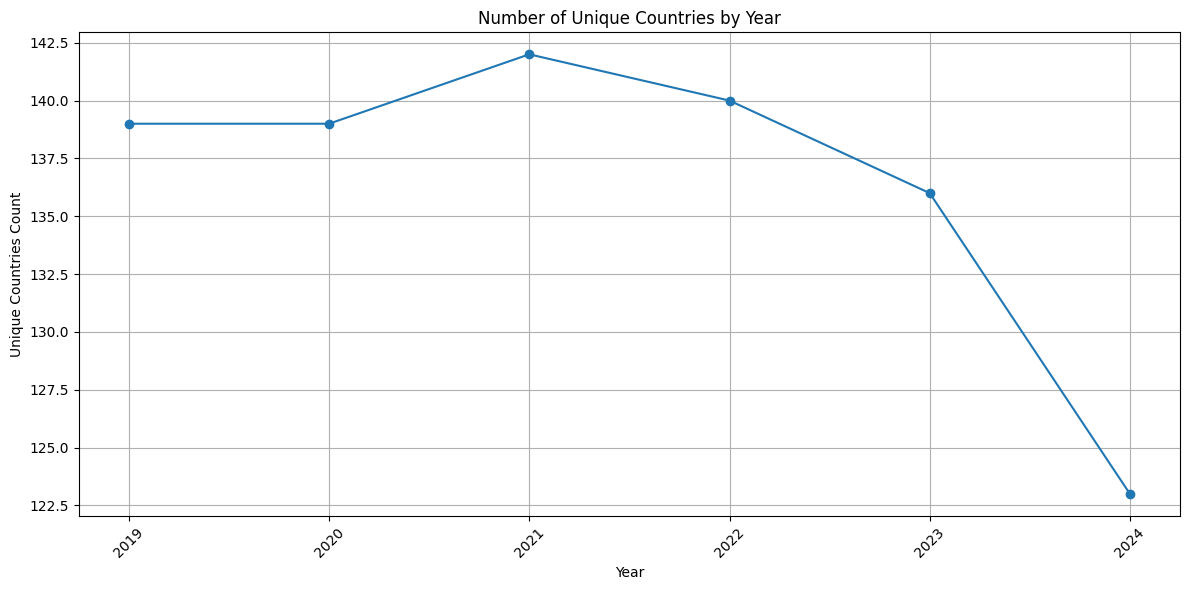

In [31]:
# Group by year and count unique countries
unique_countries_per_year = combined_df.groupby('refYear')['reporterDesc'].nunique().reset_index()

# Rename the columns for clarity
unique_countries_per_year.columns = ['Year', 'Unique Countries Count']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(unique_countries_per_year['Year'], unique_countries_per_year['Unique Countries Count'], marker='o')
plt.title('Number of Unique Countries by Year')
plt.xlabel('Year')
plt.ylabel('Unique Countries Count')
plt.xticks(ticks=unique_countries_per_year['Year'], labels=unique_countries_per_year['Year'].astype(int), rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

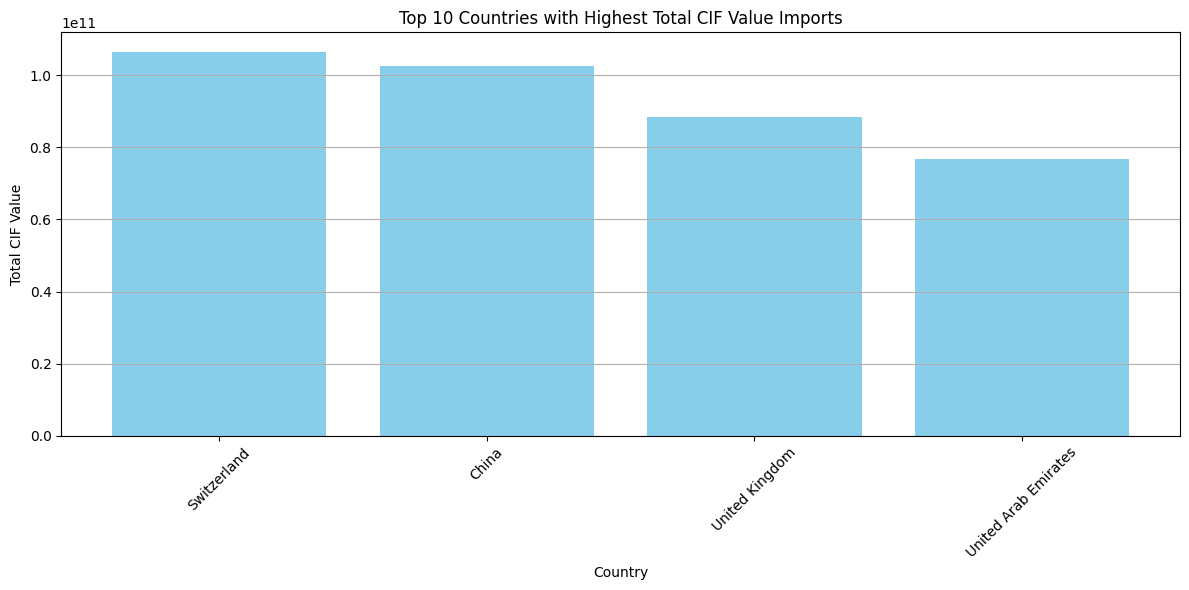

In [32]:
top_countries = grouped_data.sort_values(by='cifvalue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_countries['reporterDesc'], top_countries['cifvalue'], color='skyblue')
plt.title('Top 10 Countries with Highest Total CIF Value Imports')
plt.xlabel('Country')
plt.ylabel('Total CIF Value')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

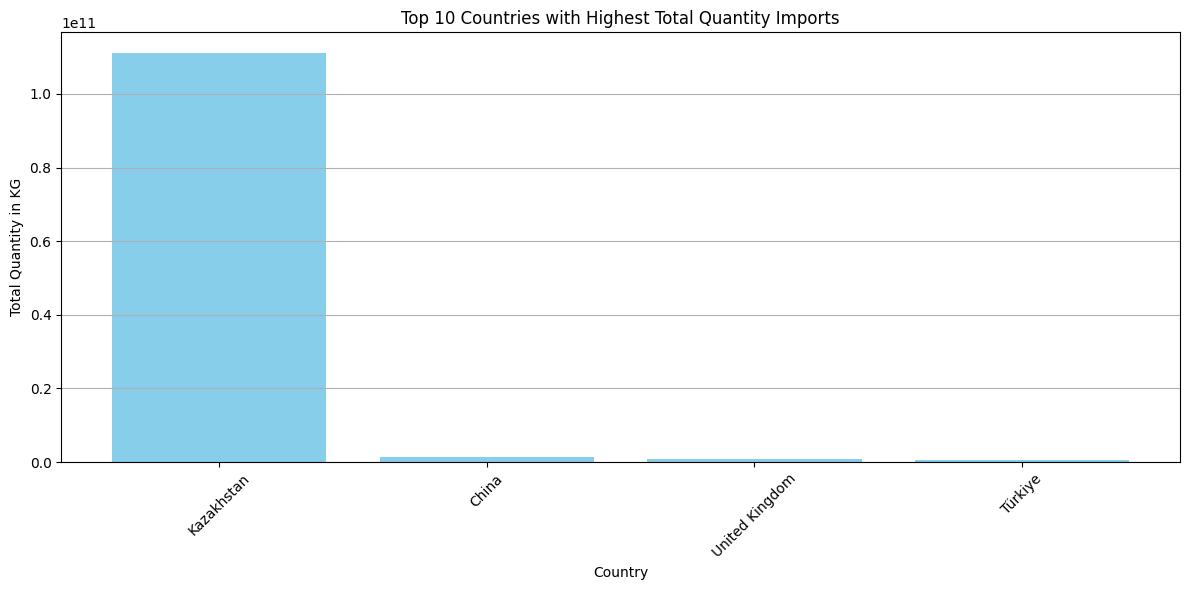

In [33]:
# Grouping the data by quantity
grouped_data_qty = combined_df.groupby(['reporterDesc', 'refYear'])['altQty'].sum().reset_index()

top_countries_qty = grouped_data_qty.sort_values(by='altQty', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_countries_qty['reporterDesc'], top_countries_qty['altQty'], color='skyblue')
plt.title('Top 10 Countries with Highest Total Quantity Imports')
plt.xlabel('Country')
plt.ylabel('Total Quantity in KG')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [37]:
# data cleaning
data = combined_df[['refYear', 'reporterDesc', 'cifvalue']].dropna()

In [38]:
# Group by country and year, summing the cifvalue for each combination
grouped_data = data.groupby(['reporterDesc', 'refYear']).sum().reset_index()

In [39]:
# Prepare to store future predictions
future_results = pd.DataFrame()

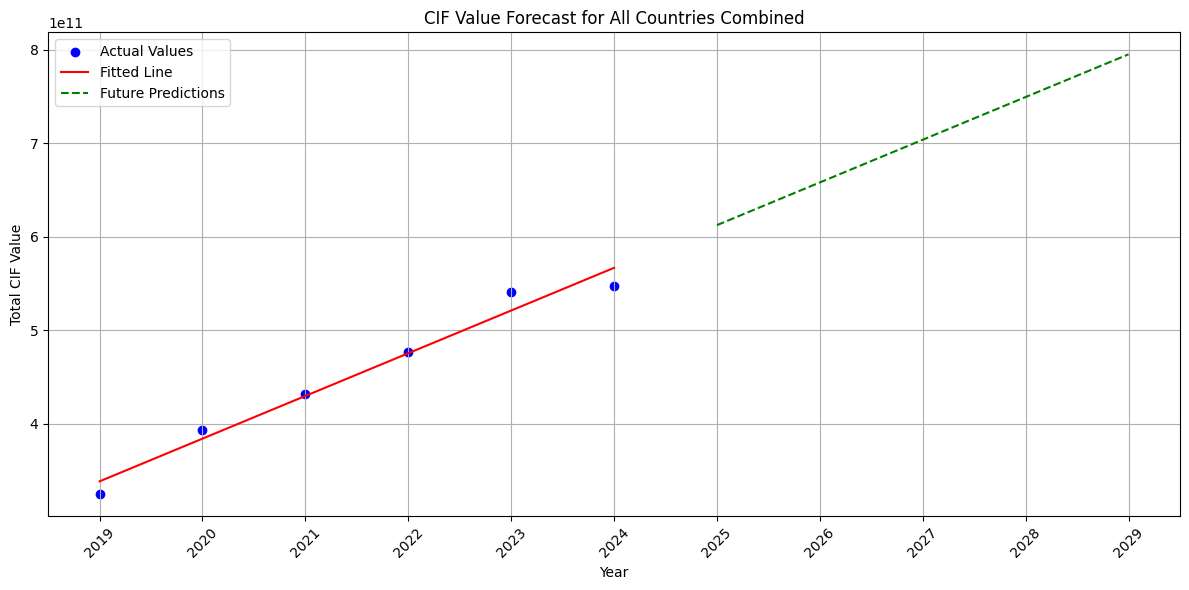

   Year  Predicted CIF Value
0  2025         6.123133e+11
1  2026         6.579902e+11
2  2027         7.036670e+11
3  2028         7.493438e+11
4  2029         7.950207e+11


In [41]:
# Group by year, summing the cifvalue for all countries
grouped_data = combined_df.groupby('refYear')['cifvalue'].sum().reset_index()

# Prepare the feature and target variables
X = grouped_data[['refYear']]
y = grouped_data['cifvalue']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Forecasting future values (e.g., for the next 5 years)
future_years = pd.DataFrame({'refYear': np.arange(grouped_data['refYear'].max() + 1, grouped_data['refYear'].max() + 6)})
future_predictions = model.predict(future_years)

# Create the plot for historical data and forecast
plt.figure(figsize=(12, 6))
plt.scatter(grouped_data['refYear'], grouped_data['cifvalue'], color='blue', label='Actual Values')
plt.plot(grouped_data['refYear'], model.predict(X), color='red', label='Fitted Line')
plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
plt.title('CIF Value Forecast for All Countries Combined')
plt.xlabel('Year')
plt.ylabel('Total CIF Value')
# Set x-ticks to show all years in the dataset
all_years = np.arange(grouped_data['refYear'].min(), future_years['refYear'].max() + 1)
plt.xticks(all_years, rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Display future predictions
future_results = pd.DataFrame({'Year': future_years['refYear'], 'Predicted CIF Value': future_predictions})
print(future_results)

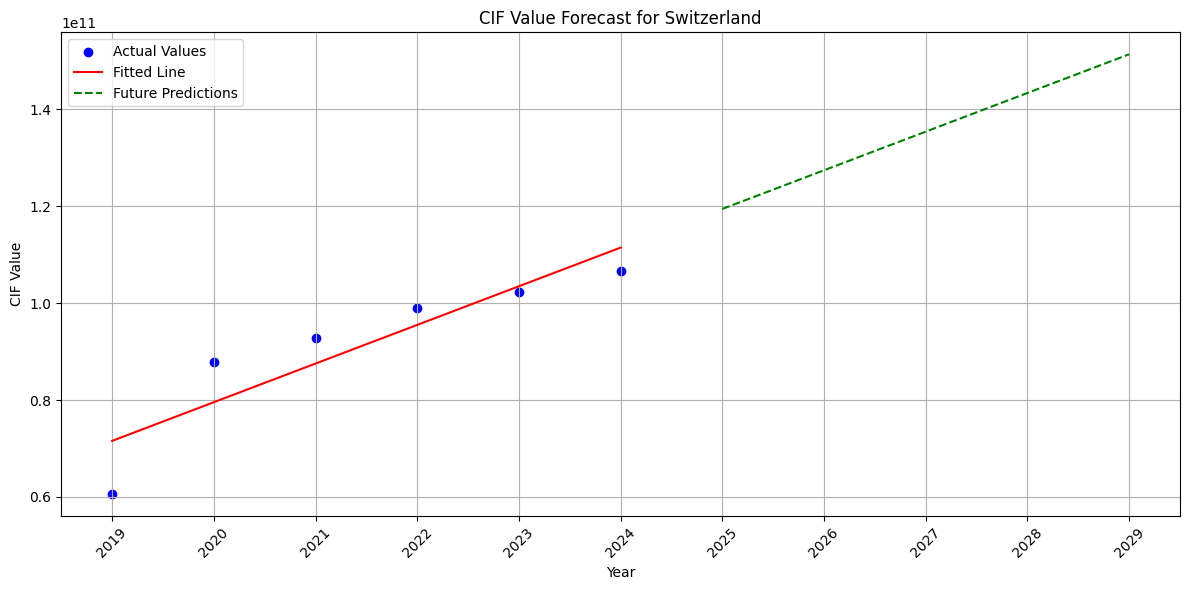

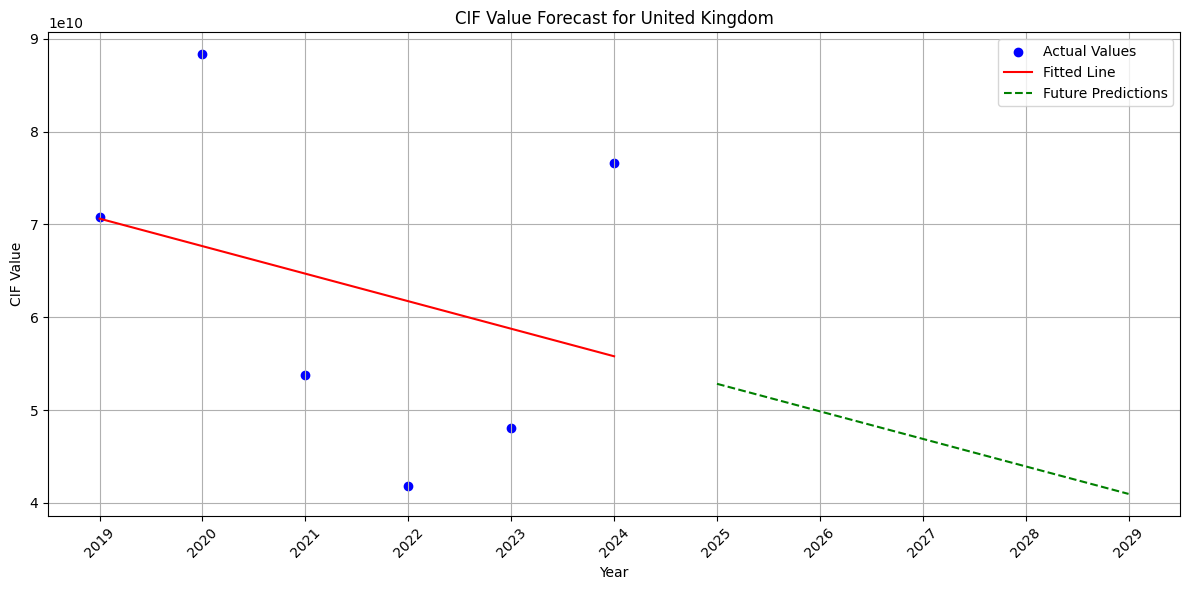

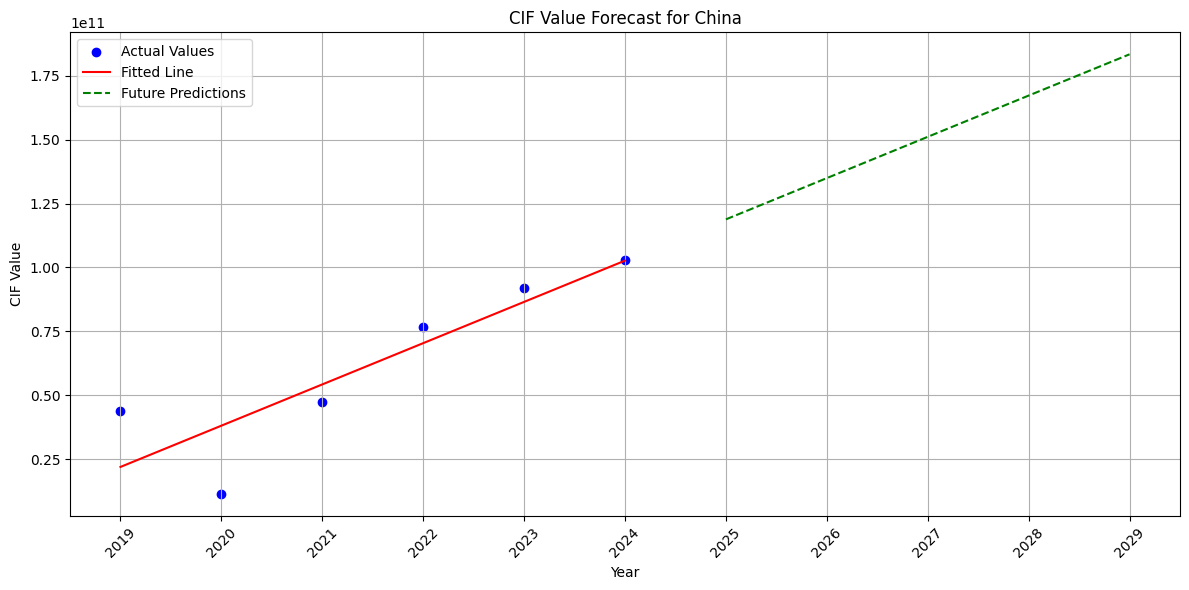

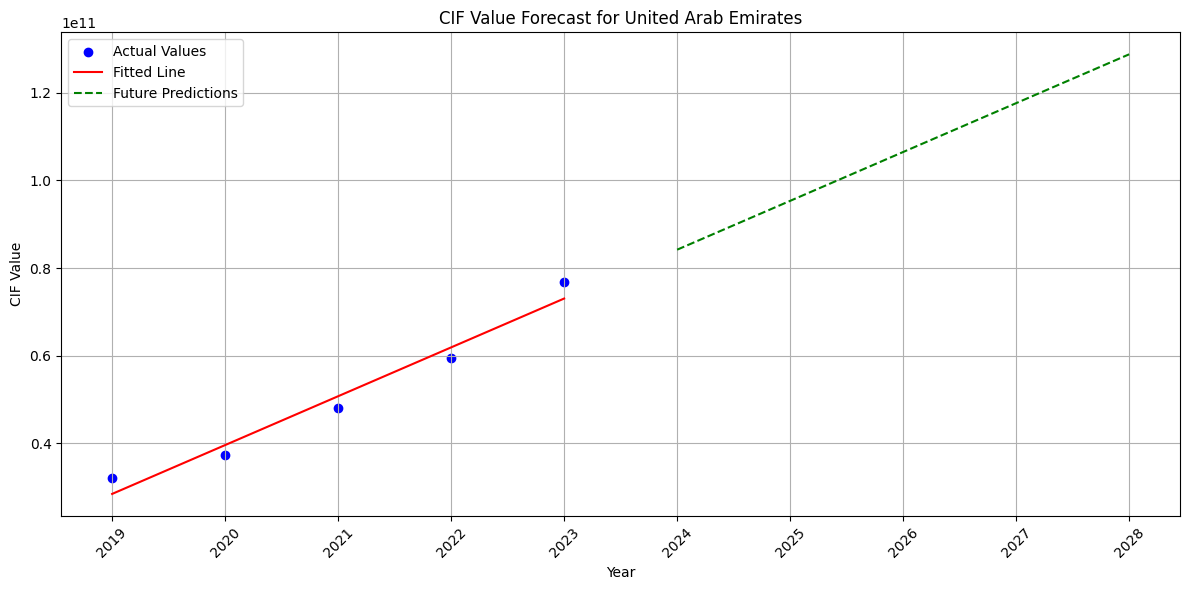

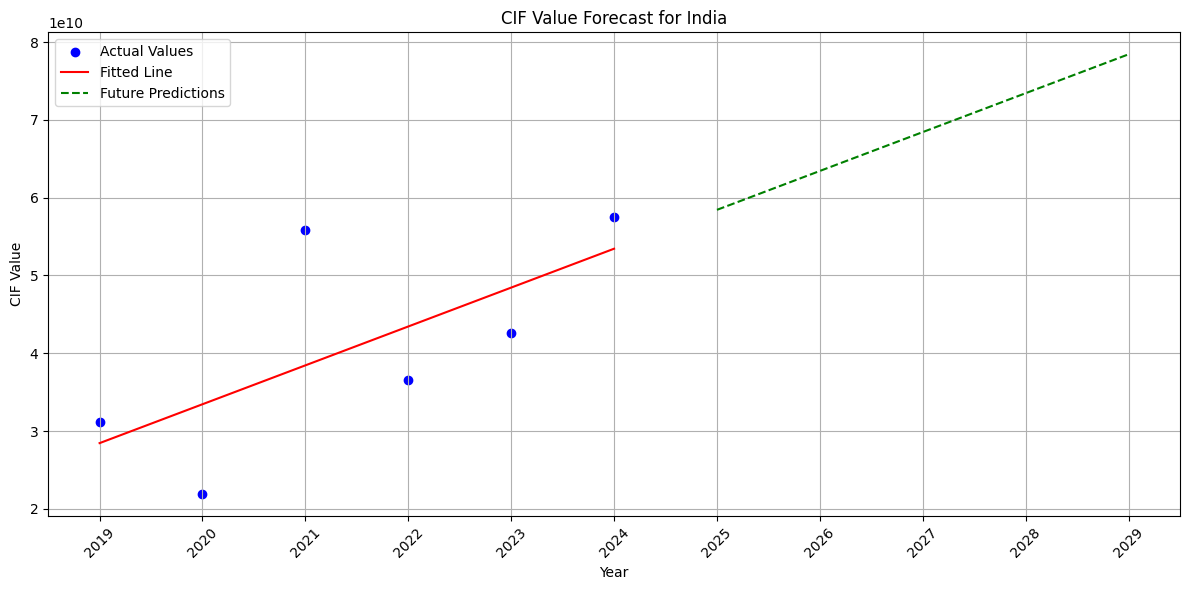

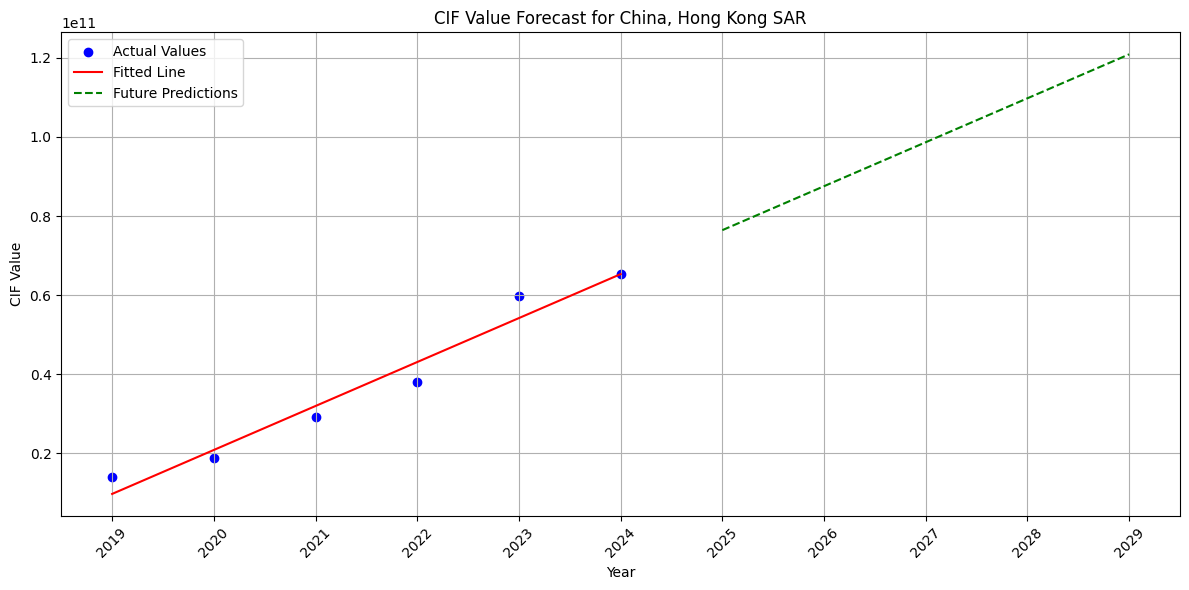

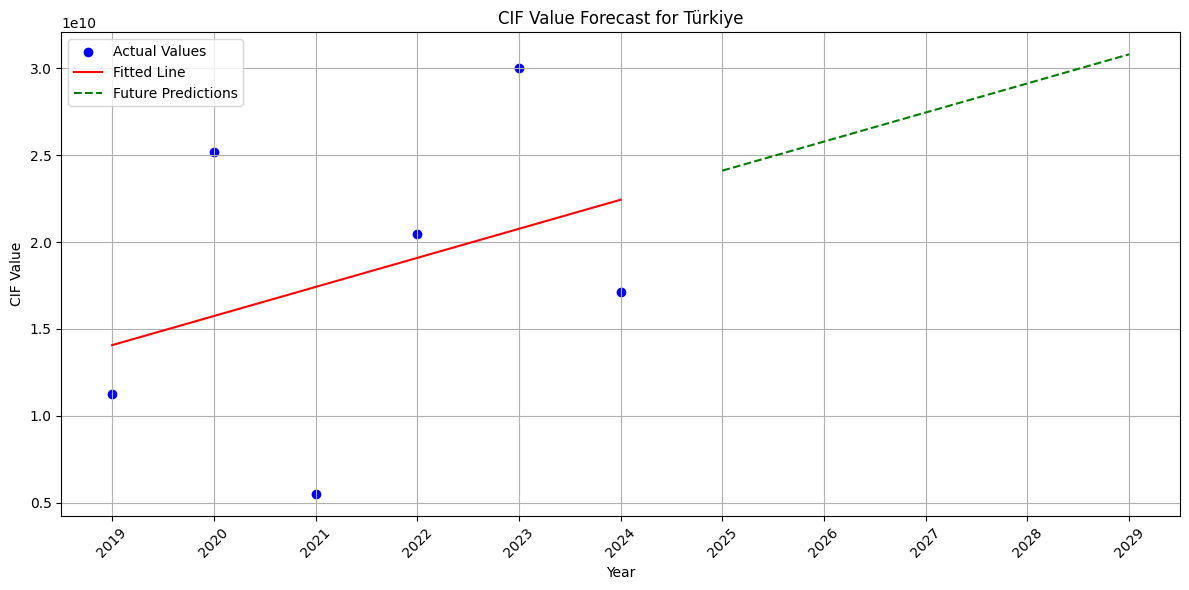

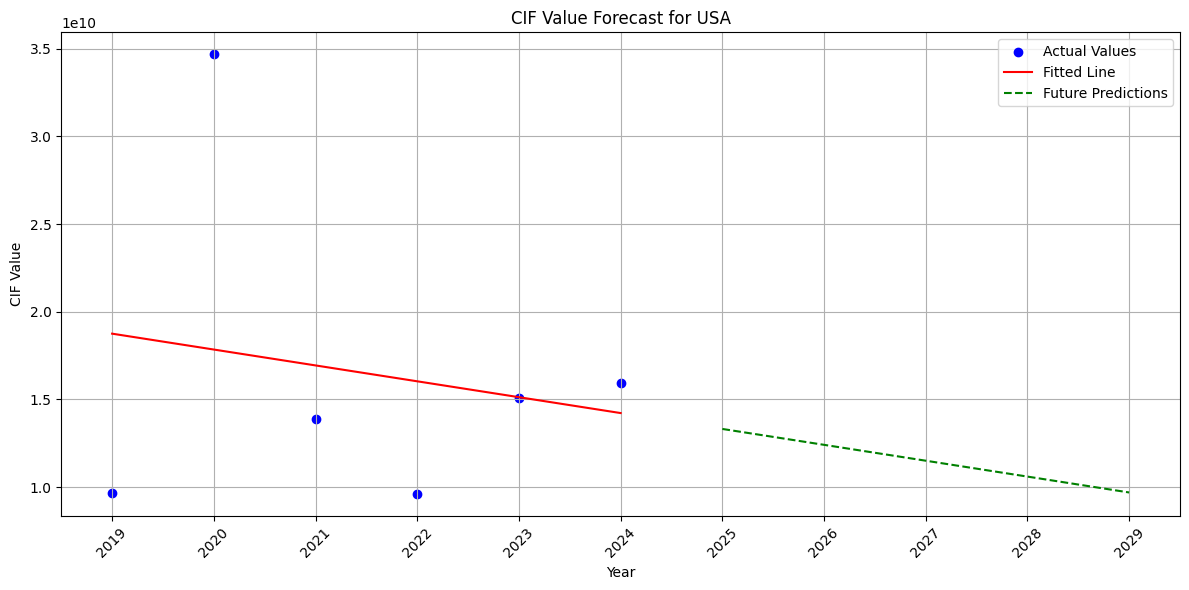

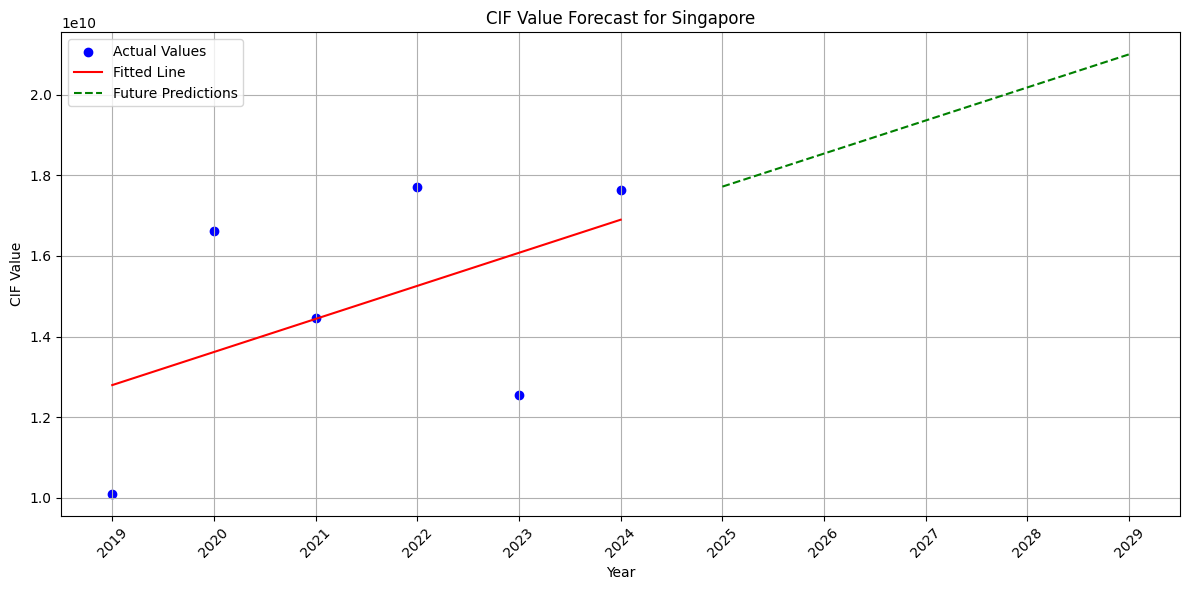

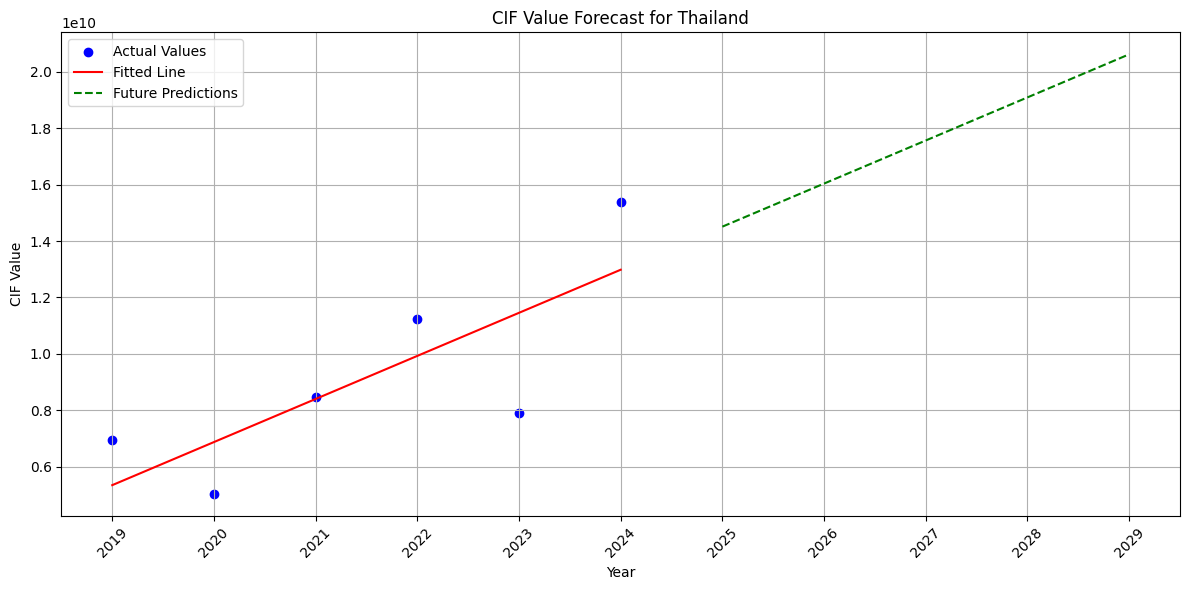

                 Country  Year  Predicted CIF Value
0            Switzerland  2025         1.194233e+11
1            Switzerland  2026         1.273985e+11
2            Switzerland  2027         1.353737e+11
3            Switzerland  2028         1.433490e+11
4            Switzerland  2029         1.513242e+11
5         United Kingdom  2025         5.282537e+10
6         United Kingdom  2026         4.985840e+10
7         United Kingdom  2027         4.689143e+10
8         United Kingdom  2028         4.392446e+10
9         United Kingdom  2029         4.095749e+10
10                 China  2025         1.187994e+11
11                 China  2026         1.349377e+11
12                 China  2027         1.510760e+11
13                 China  2028         1.672143e+11
14                 China  2029         1.833526e+11
15  United Arab Emirates  2024         8.420764e+10
16  United Arab Emirates  2025         9.535536e+10
17  United Arab Emirates  2026         1.065031e+11
18  United A

In [42]:
# cif value forecast for the top 10 countries

# Group by country and year, summing the cifvalue for each combination
grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['cifvalue'].sum().reset_index()

# Identify the top 10 countries based on the total CIF value
top_countries = grouped_data.groupby('reporterDesc')['cifvalue'].sum().reset_index()
top_countries = top_countries.sort_values(by='cifvalue', ascending=False).head(10)

# Prepare to store future predictions
future_results = pd.DataFrame()

# Loop through each top country to apply linear regression
for country in top_countries['reporterDesc']:
    country_data = grouped_data[grouped_data['reporterDesc'] == country]

    # Prepare the feature and target variables
    X = country_data[['refYear']]
    y = country_data['cifvalue']

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Forecasting future values (e.g., for the next 5 years)
    future_years = pd.DataFrame({'refYear': np.arange(country_data['refYear'].max() + 1, country_data['refYear'].max() + 6)})
    future_predictions = model.predict(future_years)

    # Store future predictions for each country
    future_country_results = pd.DataFrame({'Country': country, 'Year': future_years['refYear'], 'Predicted CIF Value': future_predictions})
    future_results = pd.concat([future_results, future_country_results], ignore_index=True)

    # Plotting the results for each country
    plt.figure(figsize=(12, 6))
    plt.scatter(country_data['refYear'], country_data['cifvalue'], color='blue', label='Actual Values')
    plt.plot(country_data['refYear'], model.predict(X), color='red', label='Fitted Line')
    plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
    plt.title(f'CIF Value Forecast for {country}')
    plt.xlabel('Year')
    plt.ylabel('CIF Value')
    # Set x-ticks to show all years in the dataset
    all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
    plt.xticks(all_years, rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Display future predictions for all top countries
print(future_results)

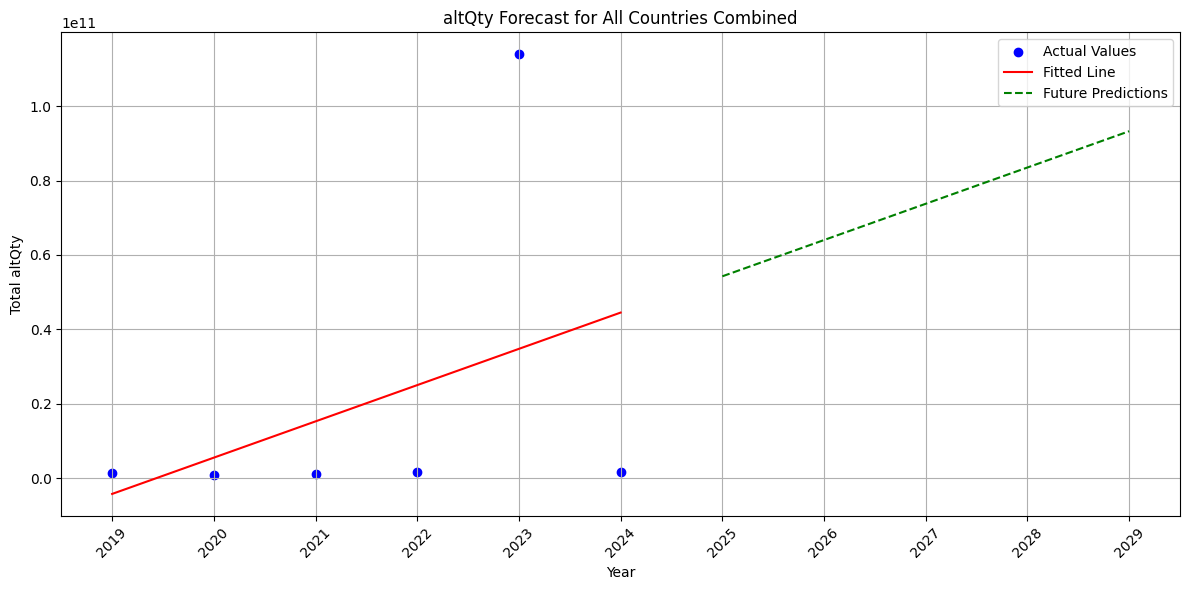

   Year  Predicted altQty
0  2025      5.426410e+10
1  2026      6.401864e+10
2  2027      7.377318e+10
3  2028      8.352772e+10
4  2029      9.328227e+10


In [43]:
# Group by year, summing the altQty for all countries
grouped_data = combined_df.groupby('refYear')['altQty'].sum().reset_index()

# Prepare the feature and target variables
X = grouped_data[['refYear']]
y = grouped_data['altQty']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Forecasting future values (e.g., for the next 5 years)
future_years = pd.DataFrame({'refYear': np.arange(grouped_data['refYear'].max() + 1, grouped_data['refYear'].max() + 6)})
future_predictions = model.predict(future_years)

# Create the plot for historical data and forecast
plt.figure(figsize=(12, 6))
plt.scatter(grouped_data['refYear'], grouped_data['altQty'], color='blue', label='Actual Values')
plt.plot(grouped_data['refYear'], model.predict(X), color='red', label='Fitted Line')
plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
plt.title('altQty Forecast for All Countries Combined')
plt.xlabel('Year')
plt.ylabel('Total altQty')
all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
plt.xticks(all_years, rotation=45)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Display future predictions
future_results = pd.DataFrame({'Year': future_years['refYear'], 'Predicted altQty': future_predictions})
print(future_results)

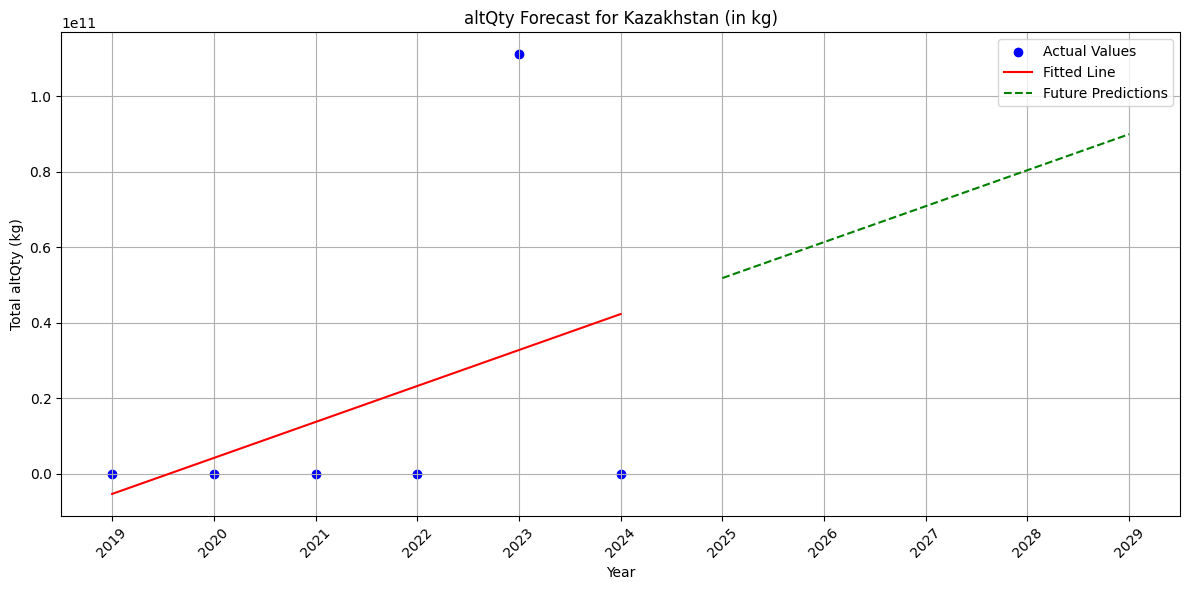

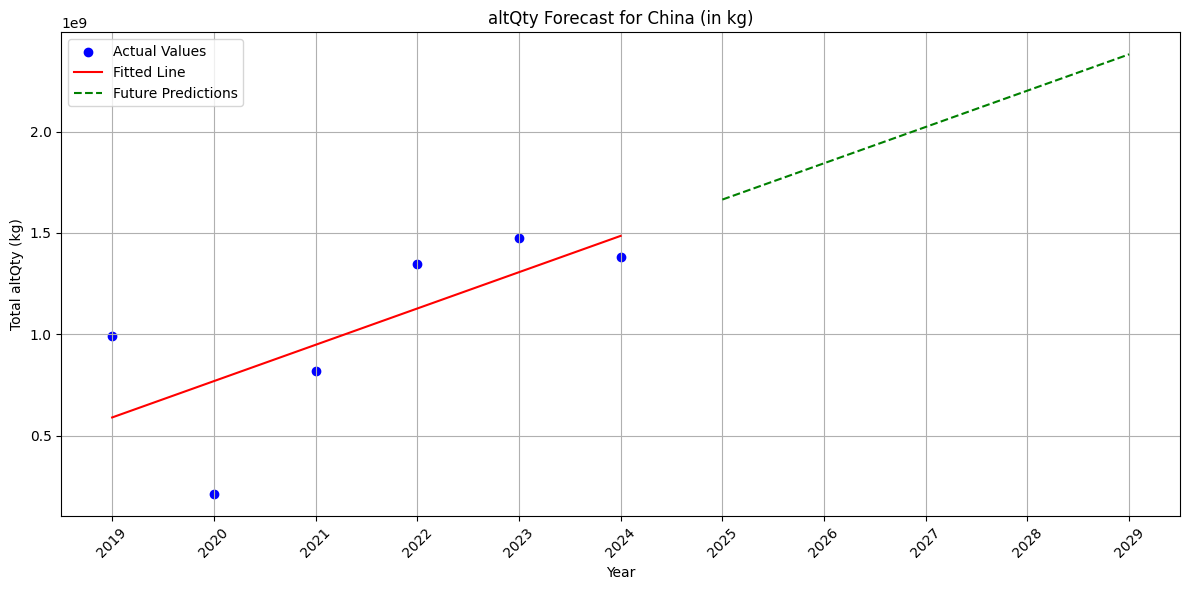

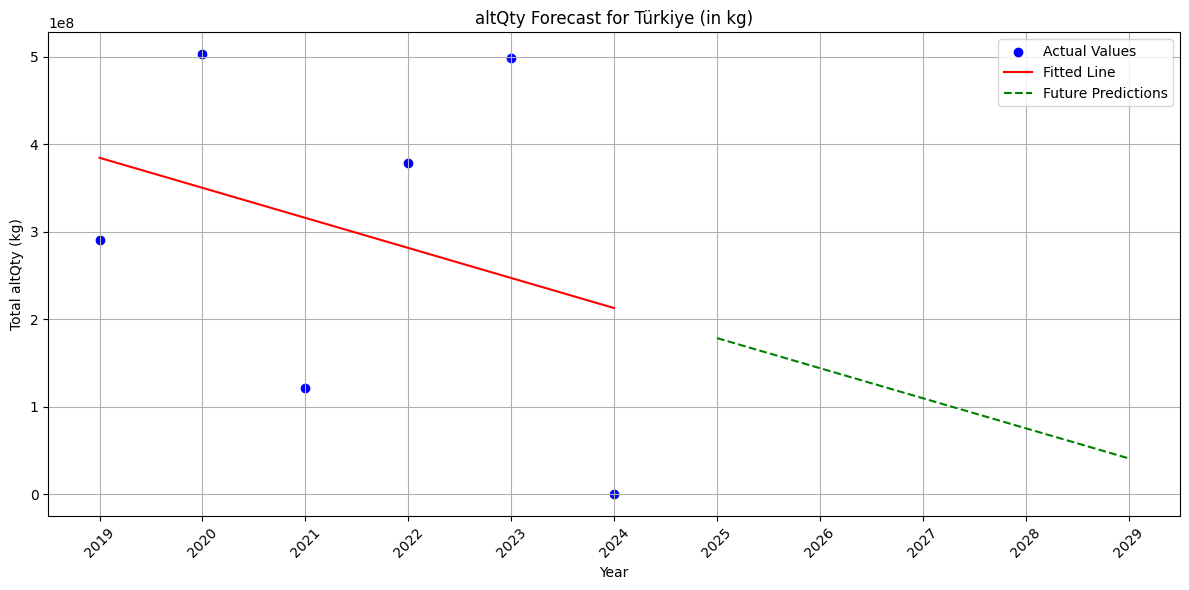

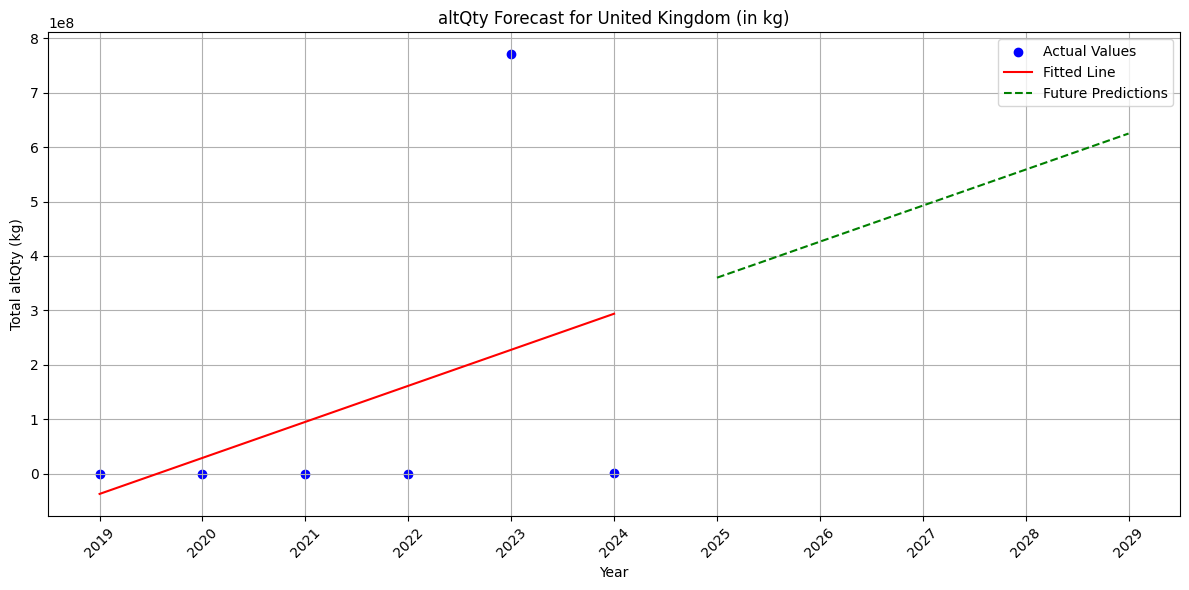

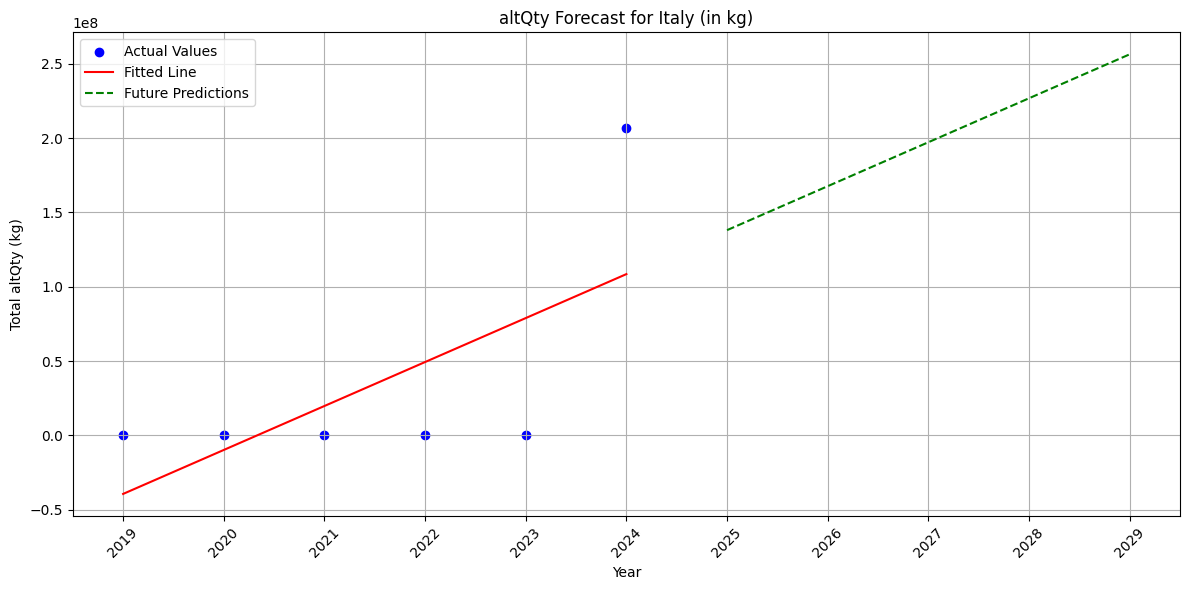

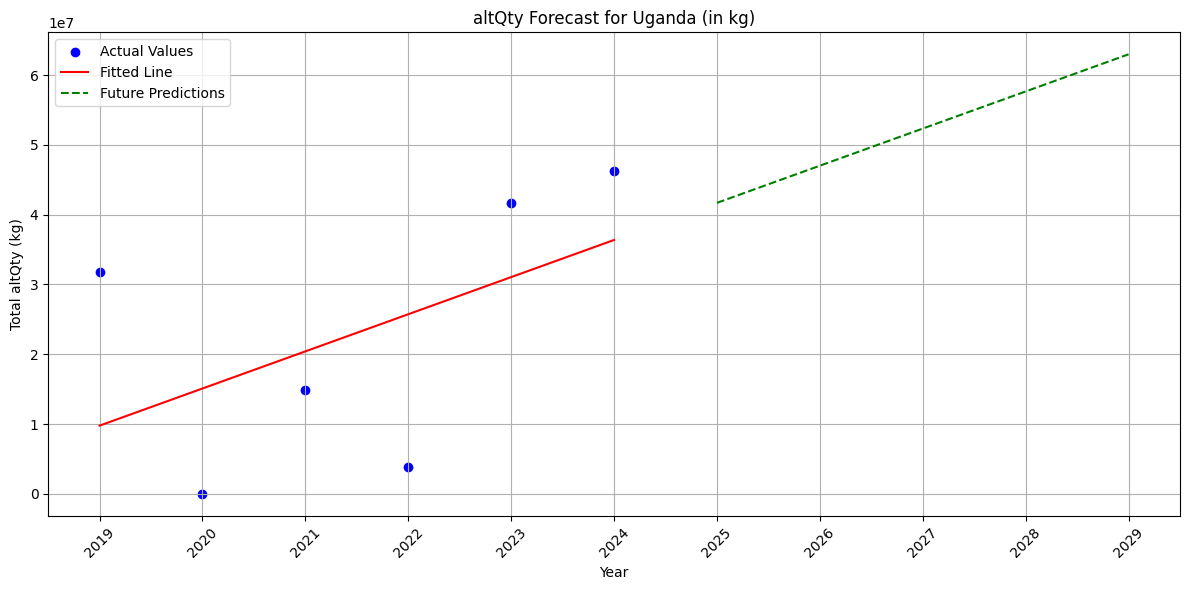

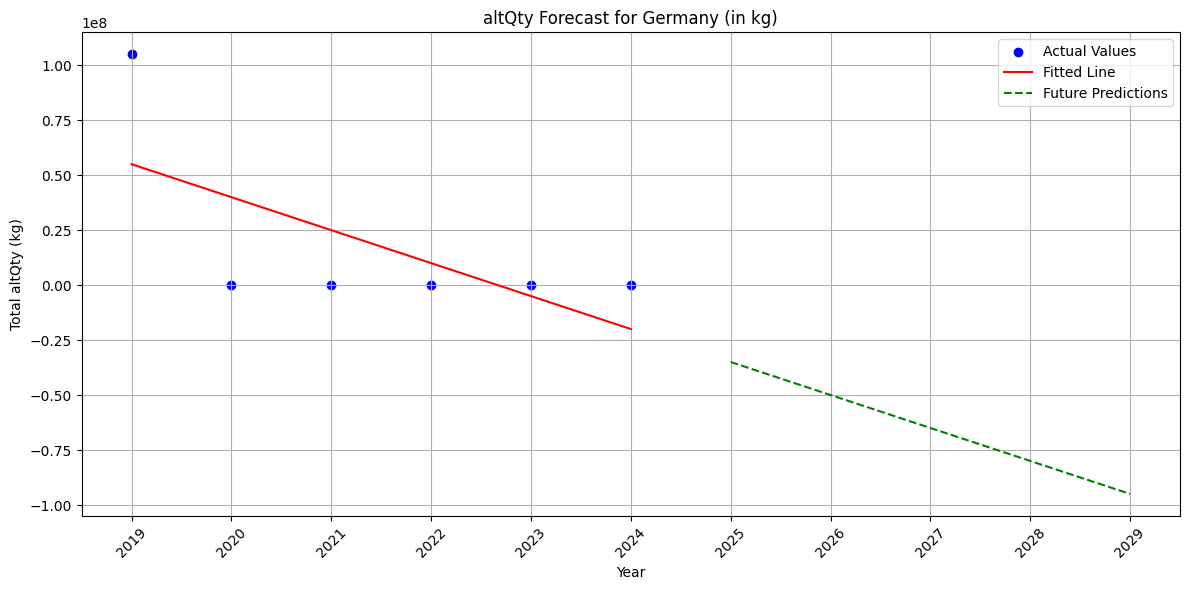

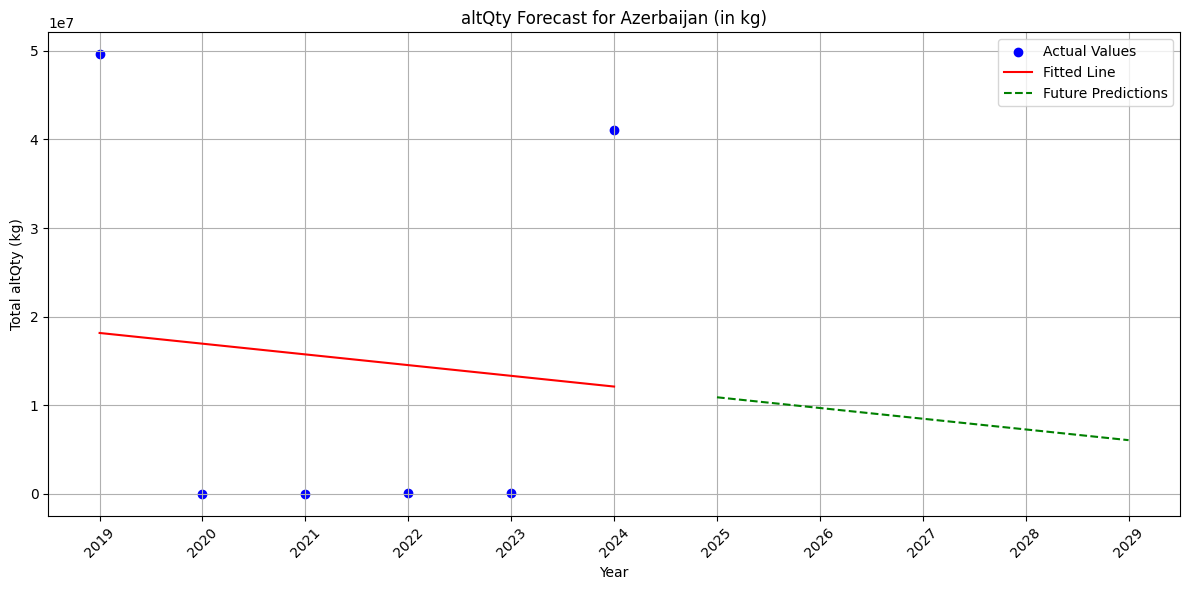

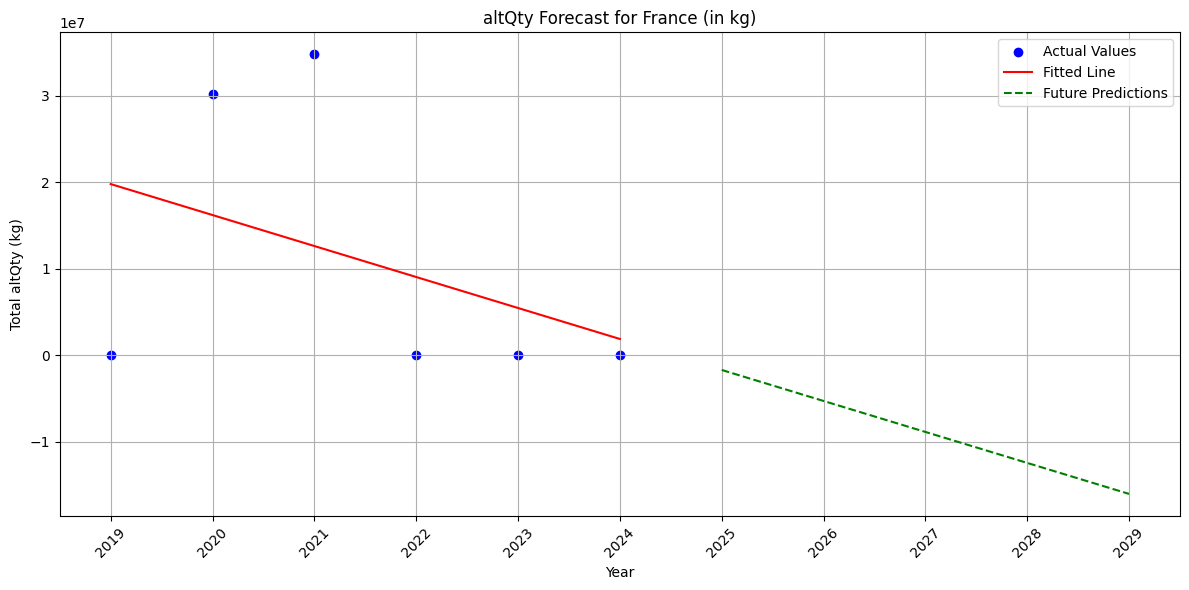

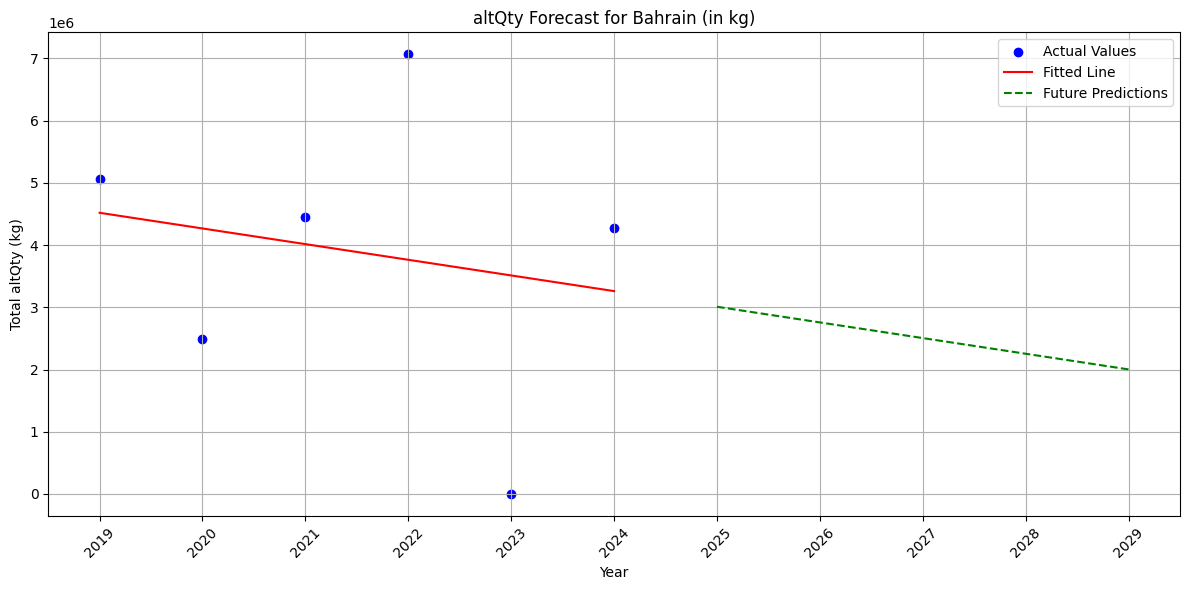

           Country  Year  Predicted altQty (kg)
0       Kazakhstan  2025           5.188169e+10
1       Kazakhstan  2026           6.141112e+10
2       Kazakhstan  2027           7.094056e+10
3       Kazakhstan  2028           8.046999e+10
4       Kazakhstan  2029           8.999943e+10
5            China  2025           1.664844e+09
6            China  2026           1.844009e+09
7            China  2027           2.023173e+09
8            China  2028           2.202338e+09
9            China  2029           2.381502e+09
10         Türkiye  2025           1.784547e+08
11         Türkiye  2026           1.440824e+08
12         Türkiye  2027           1.097101e+08
13         Türkiye  2028           7.533777e+07
14         Türkiye  2029           4.096545e+07
15  United Kingdom  2025           3.601351e+08
16  United Kingdom  2026           4.263026e+08
17  United Kingdom  2027           4.924701e+08
18  United Kingdom  2028           5.586376e+08
19  United Kingdom  2029           6.248

In [44]:


# Group by country and year, summing the altQty (in kg) for each combination
grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['altQty'].sum().reset_index()

# Identify the top 10 countries based on the total altQty
top_countries = grouped_data.groupby('reporterDesc')['altQty'].sum().reset_index()
top_countries = top_countries.sort_values(by='altQty', ascending=False).head(10)

# Prepare to store future predictions
future_results = pd.DataFrame()

# Loop through each top country to apply linear regression
for country in top_countries['reporterDesc']:
    country_data = grouped_data[grouped_data['reporterDesc'] == country]

    # Prepare the feature and target variables
    X = country_data[['refYear']]
    y = country_data['altQty']

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Forecasting future values (e.g., for the next 5 years)
    future_years = pd.DataFrame({'refYear': np.arange(country_data['refYear'].max() + 1, country_data['refYear'].max() + 6)})
    future_predictions = model.predict(future_years)

    # Store future predictions for each country
    future_country_results = pd.DataFrame({'Country': country, 'Year': future_years['refYear'], 'Predicted altQty (kg)': future_predictions})
    future_results = pd.concat([future_results, future_country_results], ignore_index=True)

    # Plotting the results for each country
    plt.figure(figsize=(12, 6))
    plt.scatter(country_data['refYear'], country_data['altQty'], color='blue', label='Actual Values')
    plt.plot(country_data['refYear'], model.predict(X), color='red', label='Fitted Line')
    plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
    plt.title(f'altQty Forecast for {country} (in kg)')
    plt.xlabel('Year')
    plt.ylabel('Total altQty (kg)')
    
    # Set x-ticks to show all years in the dataset
    all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
    plt.xticks(all_years, rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Display future predictions for all top countries
print(future_results)
